In [1]:
# Importing libraries required for data analysis and visualization
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd


In [2]:
# Loading the iPhone sales dataset into a pandas DataFrame

df = pd.read_csv("iphone_sales_dataset.csv")

In [3]:
# Displaying first 5 rows of the dataset
# Helps understand dataset structure

df.head()

,Order_ID,Customer_Name,Country,iPhone_Model,Storage,Color,Quantity,Price,Sale_Date,Payment_Method
0,1001,Customer_1,USA,iPhone 13,256GB,Purple,5,1817,2025-05-01,Debit Card
1,1002,Customer_2,Canada,iPhone 12,256GB,Blue,1,998,2025-03-05,PayPal
2,1003,Customer_3,Canada,iPhone 15 Pro Max,512GB,Black,5,876,2025-01-25,Credit Card
3,1004,Customer_4,USA,iPhone 15 Pro Max,512GB,Black,2,1290,2025-03-24,Debit Card
4,1005,Customer_5,USA,iPhone 15,128GB,Blue,3,1092,2025-02-01,Debit Card


In [6]:
# Checking number of rows and columns

df.shape

(100, 10)

In [7]:
# Displaying dataset information
# Helps identify data types and missing values

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Order_ID        100 non-null    int64 
 1   Customer_Name   100 non-null    object
 2   Country         100 non-null    object
 3   iPhone_Model    100 non-null    object
 4   Storage         100 non-null    object
 5   Color           100 non-null    object
 6   Quantity        100 non-null    int64 
 7   Price           100 non-null    int64 
 8   Sale_Date       100 non-null    object
 9   Payment_Method  100 non-null    object
dtypes: int64(3), object(7)
memory usage: 7.9+ KB


In [8]:
# Generating statistical summary for numerical columns

df.describe()

,Order_ID,Quantity,Price
count,100.000000,100.000000,100.000000
mean,1050.500000,3.330000,1468.750000
std,29.011492,1.484295,388.367637
min,1001.000000,1.000000,718.000000
25%,1025.750000,2.000000,1123.750000
50%,1050.500000,3.000000,1571.500000
75%,1075.250000,5.000000,1794.250000
max,1100.000000,5.000000,1992.000000


In [9]:
# Checking null values in dataset
# Important for data cleaning process

df.isnull().sum()

Order_ID          0
Customer_Name     0
Country           0
iPhone_Model      0
Storage           0
Color             0
Quantity          0
Price             0
Sale_Date         0
Payment_Method    0
dtype: int64

In [10]:
# Converting Sale_Date column into datetime format
# Enables time series analysis

df['Sale_Date'] = pd.to_datetime(df['Sale_Date'])

In [11]:
# Creating revenue column
# Revenue = Quantity × Price

df['Revenue'] = df['Quantity'] * df['Price']

In [12]:
# Extracting month from sale date
# Useful for monthly sales analysis

df['Month'] = df['Sale_Date'].dt.month_name()

In [13]:
# Extracting year from sale date

df['Year'] = df['Sale_Date'].dt.year

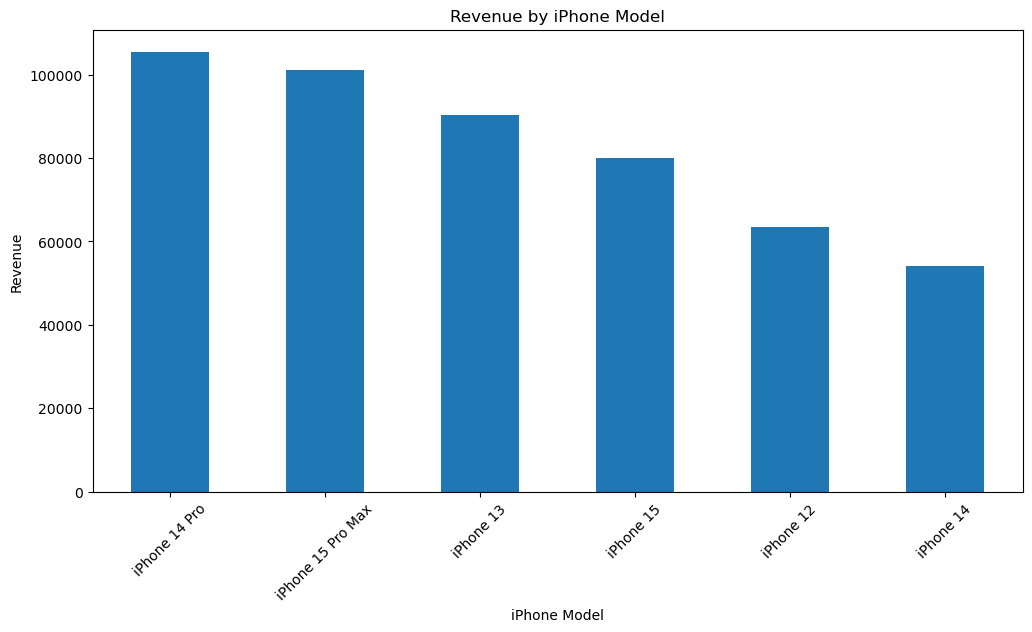

In [16]:
model_revenue =df.groupby('iPhone_Model')['Revenue'].sum()
model_revenue = model_revenue.sort_values(ascending=False)
plt.figure(figsize=(12,6))
model_revenue.plot(kind='bar')
plt.title('Revenue by iPhone Model')
plt.xlabel('iPhone Model')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.show()






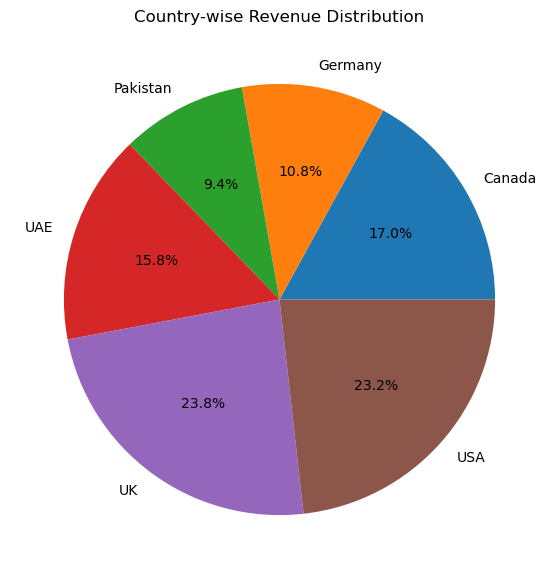

In [22]:
country_sales = df.groupby('Country')['Revenue'].sum()
plt.figure(figsize=(7,7))
country_sales.plot(
    kind='pie',
    autopct='%1.1f%%'
)
plt.title('Country-wise Revenue Distribution')
plt.ylabel('')
plt.show()

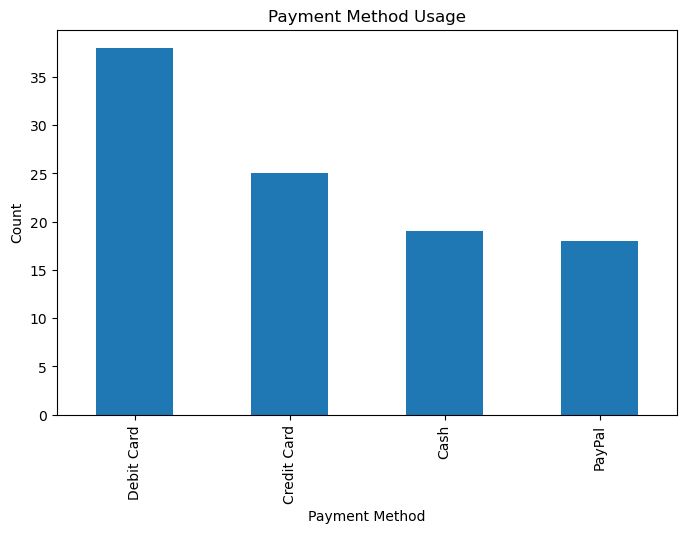

In [23]:
payment_counts = df['Payment_Method'].value_counts()
plt.figure(figsize=(8,5))
payment_counts.plot(kind='bar')
plt.title('Payment Method Usage')
plt.xlabel('Payment Method')
plt.ylabel('Count')
plt.show()

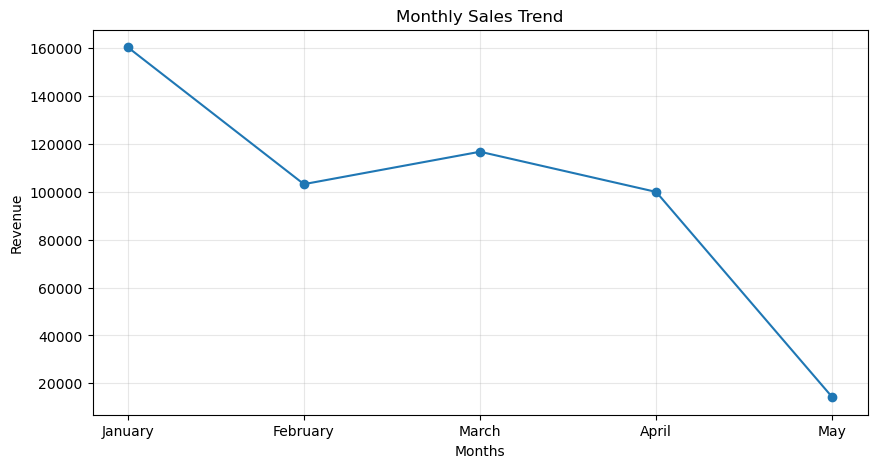

In [25]:
# Calculating monthly revenue trend

monthly_sales = df.groupby('Month')['Revenue'].sum()

# Defining correct month order

month_order = [
    'January',
    'February',
    'March',
    'April',
    'May',
    'June',
    'July',
    'August',
    'September',
    'October',
    'November',
    'December'
]

# Reordering months properly

monthly_sales = monthly_sales.reindex(month_order)

# Removing null values if some months are absent

monthly_sales = monthly_sales.dropna()

# Creating line chart

plt.figure(figsize=(10,5))

plt.plot(
    monthly_sales.index,
    monthly_sales.values,
    marker='o'
)

# Adding chart title

plt.title('Monthly Sales Trend')

# Adding x-axis label

plt.xlabel('Months')

# Adding y-axis label

plt.ylabel('Revenue')

# Adding grid for better readability

plt.grid(alpha=0.3)

# Displaying chart

plt.show()

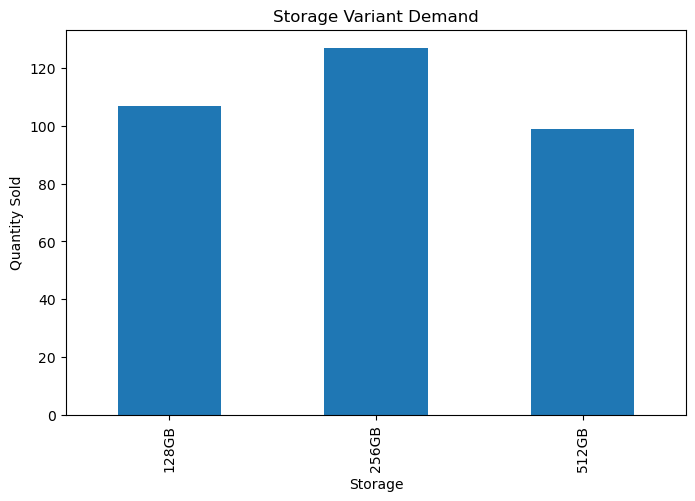

In [26]:
storage_analysis = df.groupby('Storage')['Quantity'].sum()
plt.figure(figsize=(8,5))
storage_analysis.plot(kind='bar')
plt.title('Storage Variant Demand')
plt.xlabel('Storage')
plt.ylabel('Quantity Sold')
plt.show()

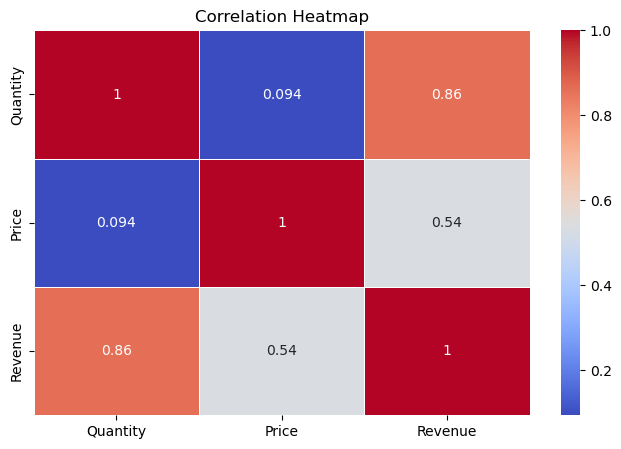

In [28]:
# Selecting only important numerical columns
# These columns help analyze relationships between sales metrics

numerical_columns = [
    'Quantity',
    'Price',
    'Revenue'
]

# Calculating correlation matrix

correlation_matrix = df[numerical_columns].corr()

# Creating heatmap

plt.figure(figsize=(8,5))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    linewidths=0.5
)

# Adding chart title

plt.title('Correlation Heatmap')

# Displaying heatmap

plt.show()

In [30]:
# Exporting cleaned dataset for Power BI dashboard

df.to_csv(
    'cleaned_iphone_sales1.csv',
    index=False
)

In [31]:
# Displaying current working directory

import os

os.getcwd()

'C:\\Users\\himan'